### Reading from CSV


In [73]:
import pandas as pd

file_path = (r"C:\\Users\\user\\anaconda_projects\\Data Analysis of Health Care\\Health_dataset.csv")
df = pd.read_csv(file_path)

print(df)

     Patient ID  Gender        Disease            Treatment  \
0     PAT-00001    Male   Tuberculosis             Dialysis   
1     PAT-00002  Female        Malaria             Dialysis   
2     PAT-00003  Female        Malaria              Surgery   
3     PAT-00004    Male         Asthma             Dialysis   
4     PAT-00005  Female       Diabetes     Physical Therapy   
...         ...     ...            ...                  ...   
7995  PAT-07996    Male       HIV/AIDS         Radiotherapy   
7996  PAT-07997  Female  Heart Disease         Chemotherapy   
7997  PAT-07998    Male         Asthma             Dialysis   
7998  PAT-07999    Male        Typhoid  Ventilation Support   
7999  PAT-08000    Male   Tuberculosis           Medication   

                   Hospital Admission Date Discharge Date Treatment Status  \
0     City General Hospital     2022-12-19     2023-01-16        Recovered   
1     City General Hospital     2023-03-29     2023-04-21        Recovered   
2     Cit

## Create the duration of each patient stay and create a group to show numbers of patients in each group.


In [81]:
df['Admission Date'] = pd.to_datetime(df['Admission Date'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])

df['Stay Duration'] =  (df['Discharge Date'] - df['Admission Date']).dt.days

df[['Admission Date', 'Discharge Date', 'Stay Duration']].head(2)




,Admission Date,Discharge Date,Stay Duration
0,2022-12-19,2023-01-16,28
1,2023-03-29,2023-04-21,23


## Group Stay Duration


In [87]:
df['Admission Date'] = pd.to_datetime(df['Admission Date'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])

df['Stay Duration'] =  (df['Discharge Date'] - df['Admission Date']).dt.days

df[['Admission Date', 'Discharge Date', 'Stay Duration']].head(2)

bins = [-1, 0, 3, 7, 14, float('inf')]
labels = [
    "Same Day",
    "1-3 Days",
    "4-7 Days",
    "8-14 Days",
    # "15-20 Days",
    "Above 20 Days"
]

df['Stay Bucket'] = pd.cut(
    df['Stay Duration'],
    bins=bins,
    labels=labels,
    right=True
)

print(df)

     Patient ID  Gender        Disease            Treatment  \
0     PAT-00001    Male   Tuberculosis             Dialysis   
1     PAT-00002  Female        Malaria             Dialysis   
2     PAT-00003  Female        Malaria              Surgery   
3     PAT-00004    Male         Asthma             Dialysis   
4     PAT-00005  Female       Diabetes     Physical Therapy   
...         ...     ...            ...                  ...   
7995  PAT-07996    Male       HIV/AIDS         Radiotherapy   
7996  PAT-07997  Female  Heart Disease         Chemotherapy   
7997  PAT-07998    Male         Asthma             Dialysis   
7998  PAT-07999    Male        Typhoid  Ventilation Support   
7999  PAT-08000    Male   Tuberculosis           Medication   

                   Hospital Admission Date Discharge Date Treatment Status  \
0     City General Hospital     2022-12-19     2023-01-16        Recovered   
1     City General Hospital     2023-03-29     2023-04-21        Recovered   
2     Cit

### Find Number of patient on each group


In [89]:
total_group_patient = df['Stay Bucket'].value_counts()
print(total_group_patient)

Stay Bucket
Above 20 Days    4269
8-14 Days        1837
4-7 Days         1087
1-3 Days          807
Same Day            0
Name: count, dtype: int64


## Create a chart to Visualize 

Text(0.5, 1.0, 'Total Patients by lenght of Stay')

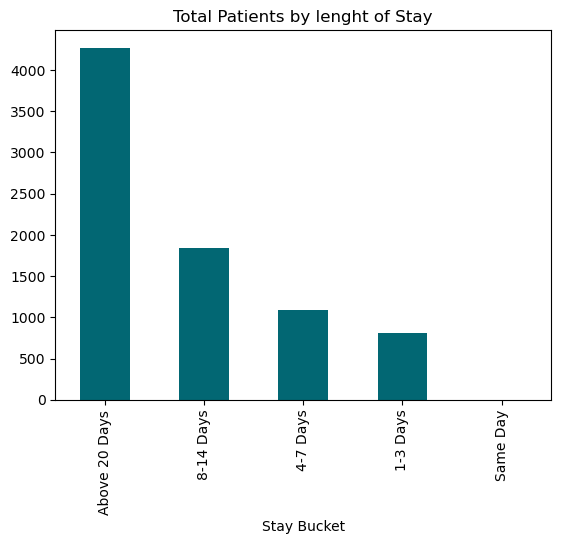

In [93]:
import matplotlib.pyplot as plt
total_group_patient.plot(kind='bar', color=['#026773'])
plt.title('Total Patients by lenght of Stay')